# Destek Vektör Regresyonu - Support Vector Regression - SVR

SVM algoritmalarının regresyon problemlerinde kullanımı ve model parametrelerinin regresyon doğrusu üzerindeki etkisinin incelenmesi.

## Sınıflandırma ve Regresyon Arasındaki Mantık Farkı

- **Sınıflandırmada amaç:** İki sınıfı ayıran boşluğu maksimum tutarken, marj sınırlarının içine giren ihlal noktalarının sayısını en aza indirmektir.
- **Regresyonda amaç:** Belirli bir $\epsilon$ (epsilon) genişliğinde sabit bir marj tüpü (sokak) oluşturarak, **mümkün olan en fazla veri noktasını bu tüpün içine sığdırmaktır**. Regresyonda marj ihlali, tüpün dışına taşan veri noktaları.

## Epsilon ($\epsilon$) Hiperparametresi ve Duyarsızlık

SVR modelinde regresyon doğrusunun üstüne ve altına $\epsilon$ genişliğinde sınırlar çizilir. 
Eğer bir veri noktasının gerçek değeri ile modelin tahmini arasındaki fark $\epsilon$ değerinden küçük veya eşitse, hata sıfır kabul edilir. Bu durum şu formülle ifade edilir:

$$|y_i - f(x_i)| \le \epsilon$$

### Sınır İhlalleri ve Gevşeklik Değişkenleri

Veri noktalarının $\epsilon$-tüpü içine sığmadığı durumlar için sisteme iki farklı gevşeklik değişkeni eklenir:
- $\xi_i$: Veri noktasının, tüpün üst sınırından ne kadar yukarıda kaldığını ölçer.
- $\xi_i^*$: Veri noktasının, tüpün alt sınırından ne kadar aşağıda kaldığını ölçer.

SVR optimizasyon problemi bu ihlalleri minimize etmeye çalışır:
$$\min_{w, b, \xi, \xi^*} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^n (\xi_i + \xi_i^*)$$

### Regresyonda C Parametresinin Rolü
- **Büyük C**: Tüpün dışındaki hatalara verilen ceza çok büyüktür. Model, tüm noktaları marj sınırına sığdırmak için eğriyi çok fazla büker --> aşırı öğrenme riski, düşük regülarizasyon.
- **Küçük C**: Dışarıdaki hatalara tolerans gösterilir. Model çizgisini olabildiğince düz tutmaya odaklanır --> yüksek regülarizasyon.

## SVR Uygulaması

Scikit-Learn `LinearSVR` ile basit bir regresyon modeli:

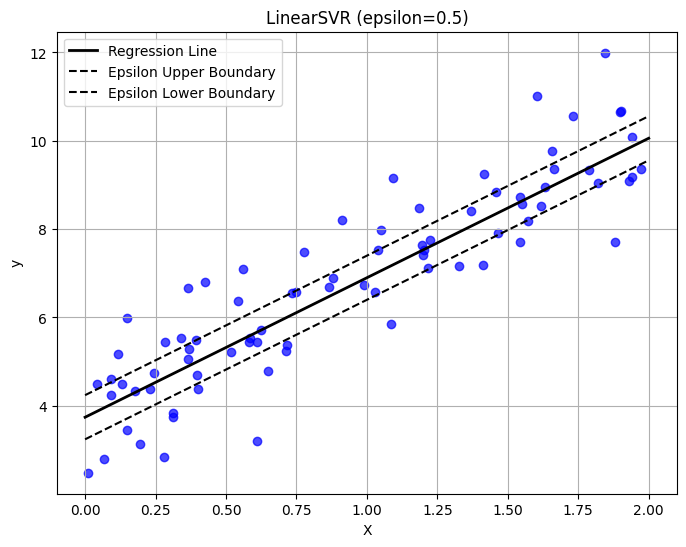

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVR

# Rastgele doğrusal veri kümesinin üretilmesi
np.random.seed(42)
m = 80
X = 2 * np.random.rand(m, 1)
y = (4 + 3 * X + np.random.randn(m, 1)).ravel()

# LinearSVR modelinin kurulması (epsilon tüp genişliğini belirler)
svm_reg = LinearSVR(epsilon=0.5, C=1.0, random_state=42)
svm_reg.fit(X, y)

# Tahminlerin ve tüp sınırlarının hesaplanması
X_new = np.linspace(0, 2, 100).reshape(-1, 1)
y_pred = svm_reg.predict(X_new)
eps = svm_reg.epsilon

plt.figure(figsize=(8, 6))
plt.plot(X_new, y_pred, "k-", linewidth=2, label="Regression Line")
plt.plot(X_new, y_pred + eps, "k--", label="Epsilon Upper Boundary")
plt.plot(X_new, y_pred - eps, "k--", label="Epsilon Lower Boundary")
plt.scatter(X, y, color="blue", alpha=0.7)
plt.title(f"LinearSVR (epsilon={eps})")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()